<a href="https://colab.research.google.com/github/ciptomx/Clustering-cici/blob/main/clusteringCici_Revisi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
from google.colab import drive

# mount drive
drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/dataset'
output_filename = 'data-aws-harian-bersih-2021-2025.xlsx'

# threshold filter data
MAX_RAIN_MENIT = 4.0
MAX_RAIN_HARI = 150.0
ERROR_PRESSURE = 973.0  # sensor sering nyangkut di angka ini

def process_aws_data(folder, start_year, end_year):
    all_daily =[]

    for year in range(start_year, end_year + 1):
        file_path = os.path.join(folder, f'data-aws-{year}.xlsx')

        if not os.path.exists(file_path):
            print(f"skip {year}, filenya ga ada.")
            continue

        print(f"processing tahun {year}...")

        try:
            # load data mentah
            df = pd.read_excel(file_path)
            df.columns = df.columns.str.strip()

            # set waktu jadi index
            df['waktu'] = pd.to_datetime(df['waktu'], dayfirst=True)
            df = df.sort_values('waktu').set_index('waktu')

            # 1. bersihin data hujan (level menit)
            rain_cols =[c for c in df.columns if 'rain' in c.lower() or 'hujan' in c.lower()]
            if rain_cols:
                r_col = rain_cols[0]
                rain_diff = df[r_col].diff()

                # kalo sensor ke-reset, ambil nilai awalnya
                is_reset = rain_diff < 0
                rain_diff[is_reset] = df.loc[is_reset, r_col]

                # buang glitch sensor
                rain_diff[rain_diff > MAX_RAIN_MENIT] = 0
                df['curah_hujan'] = rain_diff.fillna(0)
                df.drop(columns=[r_col], inplace=True)

            # 2. pisahin suhu max, min, avg
            temp_cols =[c for c in df.columns if ('temp' in c.lower() or 'suhu' in c.lower())
                         and 'min' not in c.lower() and 'max' not in c.lower()]
            if temp_cols:
                t_col = temp_cols[0]
                df['suhu_maksimum'] = df[t_col]
                df['suhu_minimum'] = df[t_col]
                df.rename(columns={t_col: 'suhu_rata_rata'}, inplace=True)

            # 3. rules resample ke harian
            agg_rules = {}
            for col in df.columns:
                if 'curah_hujan' in col:
                    agg_rules[col] = 'sum'
                elif col == 'suhu_maksimum':
                    agg_rules[col] = 'max'
                elif col == 'suhu_minimum':
                    agg_rules[col] = 'min'
                else:
                    agg_rules[col] = 'mean'

            # resample & drop baris yg kosong melompong
            df_daily = df.resample('D').agg(agg_rules)
            df_daily.dropna(how='all', inplace=True)
            all_daily.append(df_daily)

        except Exception as e:
            print(f"error di tahun {year}: {e}")

    # gabungin semua tahun
    if not all_daily:
        return None, None

    final_df = pd.concat(all_daily)

    # simpan copy data mentah buat preview perbandingan nanti
    df_raw = final_df.copy()
    missing_awal = final_df.isna().sum().sum()

    # 4. handle error pressure (anomali 973)
    press_cols =[c for c in final_df.columns if 'pressure' in c.lower() or 'press' in c.lower() or 'tekanan' in c.lower()]
    outlier_count = 0
    outlier_idx =[]
    p_col = None

    if press_cols:
        p_col = press_cols[0]
        # masking nilai error (di-round buat jaga-jaga ada koma efek rata-rata)
        outliers_mask = final_df[p_col].round() == ERROR_PRESSURE
        outlier_count = outliers_mask.sum()
        outlier_idx = final_df[outliers_mask].index

        # replace ke NaN terus di-interpolasi
        final_df.loc[outliers_mask, p_col] = np.nan
        final_df[p_col] = final_df[p_col].interpolate(method='linear')

    # 5. beresin sisa missing value global
    final_df = final_df.interpolate(method='linear').bfill().ffill()
    missing_akhir = final_df.isna().sum().sum()

    # 6. limit (clip) ujan maksimal
    if 'curah_hujan' in final_df.columns:
        final_df['curah_hujan_capped'] = final_df['curah_hujan'].clip(upper=MAX_RAIN_HARI)

    # bungkus stats buat log
    stats = {
        'missing_awal': missing_awal,
        'missing_akhir': missing_akhir,
        'outlier_count': outlier_count,
        'outlier_idx': outlier_idx,
        'p_col': p_col,
        'df_raw': df_raw
    }

    return final_df, stats


# --- run pipeline ---
print("mulai proses & imputasi data...")
df_result, stats = process_aws_data(folder_path, 2021, 2025)

if df_result is not None:
    # save
    save_path = os.path.join(folder_path, output_filename)
    df_result.to_excel(save_path)

    # print log ala kadarnya
    print("\n--- Summary Preprocessing ---")
    print(f"Anomali pressure (973 hPa) : {stats['outlier_count']} baris")
    print(f"Missing value sblm proses  : {stats['missing_awal']} sel")
    print(f"Missing value ssdh proses  : {stats['missing_akhir']} sel")
    print("-" * 29)

    # preview perbandingan data
    if stats['outlier_count'] > 0 and stats['p_col'] is not None:
        print("\nPreview interpolasi data pressure yg error:")
        sample_idx = stats['outlier_idx'][:5]
        preview = pd.DataFrame({
            f"Pressure Asli": stats['df_raw'].loc[sample_idx, stats['p_col']],
            f"Pressure Hasil Interpolasi": df_result.loc[sample_idx, stats['p_col']]
        })
        display(preview)
    else:
        print("\nPreview interpolasi missing value:")
        nan_rows = stats['df_raw'][stats['df_raw'].isna().any(axis=1)].index
        if len(nan_rows) > 0:
            sample_idx = nan_rows[:5]
            print("Sebelum:")
            display(stats['df_raw'].loc[sample_idx].head())
            print("\nSesudah:")
            display(df_result.loc[sample_idx].head())
        else:
            print("aman, ga ada missing value dari awal.")

    print(f"\ndata saved -> {save_path}")

else:
    print("gagal proses data.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
mulai proses & imputasi data...
processing tahun 2021...
processing tahun 2022...
processing tahun 2023...
processing tahun 2024...
processing tahun 2025...

--- Summary Preprocessing ---
Anomali pressure (973 hPa) : 0 baris
Missing value sblm proses  : 180 sel
Missing value ssdh proses  : 0 sel
-----------------------------

Preview interpolasi missing value:
Sebelum:


,windspeed,winddir,suhu_rata_rata,rh,pressure,solrad,netrad,watertemp,waterlevel,ta_min,ta_max,pancilevel,pancitemp,curah_hujan,suhu_maksimum,suhu_minimum
waktu,,,,,,,,,,,,,,,,
2021-08-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2022-07-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2022-07-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2022-09-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2022-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN



Sesudah:


,windspeed,winddir,suhu_rata_rata,rh,pressure,solrad,netrad,watertemp,waterlevel,ta_min,ta_max,pancilevel,pancitemp,curah_hujan,suhu_maksimum,suhu_minimum,curah_hujan_capped
waktu,,,,,,,,,,,,,,,,,
2021-08-04,0.807570,146.344869,28.656469,77.951550,1010.104489,113.502334,0.0,26.182248,1.333076,0.0,0.0,0.0,0.0,0.0,30.700000,25.000000,0.0
2022-07-20,0.329792,111.811615,28.698961,82.573607,1008.553966,1.718697,0.0,26.003824,1.544901,0.0,0.0,0.0,0.0,0.0,29.200000,28.300000,0.0
2022-07-21,0.259585,124.623229,28.197923,83.847214,1008.607932,3.437394,0.0,26.007649,1.489802,0.0,0.0,0.0,0.0,0.0,29.200000,27.400000,0.0
2022-09-25,1.164834,164.236759,28.419592,77.337502,1007.502476,154.034554,0.0,24.845081,1.716943,0.0,0.0,0.0,0.0,0.0,31.614286,25.171429,0.0
2022-09-26,1.082682,156.710524,27.867666,79.987271,1007.515763,128.422539,0.0,25.090161,1.691682,0.0,0.0,0.0,0.0,0.0,31.728571,25.042857,0.0



data saved -> /content/drive/MyDrive/dataset/data-aws-harian-bersih-2021-2025.xlsx


In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

file_bersih = '/content/drive/MyDrive/dataset/data-aws-harian-bersih-2021-2025.xlsx'

try:
    # load file yg udah mateng
    df = pd.read_excel(file_bersih, index_col='waktu')

    print("cek missing values")
    display(df.isna().sum().to_frame('null_count'))

    print("\ncek unique values:")
    display(df.nunique().to_frame('unique_count'))

    print("\nstatistik sekilas:")
    display(df.describe())

except FileNotFoundError:
    print("error: filenya tidak ditemukan?")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cek missing values


,null_count
windspeed,0
winddir,0
suhu_rata_rata,0
rh,0
pressure,0
solrad,0
netrad,0
watertemp,0
waterlevel,0
ta_min,0



cek unique values:


,unique_count
windspeed,1789
winddir,1795
suhu_rata_rata,1794
rh,1795
pressure,1794
solrad,1794
netrad,1
watertemp,1246
waterlevel,1794
ta_min,1



statistik sekilas:


,windspeed,winddir,suhu_rata_rata,rh,pressure,solrad,netrad,watertemp,waterlevel,ta_min,ta_max,pancilevel,pancitemp,curah_hujan,suhu_maksimum,suhu_minimum,curah_hujan_capped
count,1795.000000,1795.000000,1795.000000,1795.000000,1795.000000,1795.000000,1795.0,1795.000000,1795.000000,1795.0,1795.0,1795.0,1795.0,1795.000000,1795.000000,1795.000000,1795.000000
mean,1.146241,147.394644,27.722764,81.397962,1008.118526,73.643511,0.0,16.072922,321.208170,0.0,0.0,0.0,0.0,9.510641,32.232702,24.666518,9.208134
std,0.309728,40.506468,1.598583,5.998021,3.311434,66.296229,0.0,28.942149,671.528732,0.0,0.0,0.0,0.0,21.558712,1.939448,1.735207,16.445859
min,0.072008,28.422917,-13.987273,35.605455,942.257292,0.000000,0.0,-89.563814,1.122388,0.0,0.0,0.0,0.0,0.000000,24.400000,-40.100000,0.000000
25%,0.953932,119.593129,26.836019,77.369857,1007.357873,15.628287,0.0,25.400000,1.565554,0.0,0.0,0.0,0.0,0.000000,31.200000,24.200000,0.000000
50%,1.108216,142.885417,27.692758,81.816006,1008.347851,38.797753,0.0,26.200000,1.703875,0.0,0.0,0.0,0.0,2.200000,32.400000,24.600000,2.200000
75%,1.283711,169.172273,28.638159,85.888263,1009.369764,126.149662,0.0,27.305477,1.909461,0.0,0.0,0.0,0.0,11.500000,33.500000,25.200000,11.500000
max,3.000000,306.000000,35.191528,98.771615,1012.877530,346.764943,0.0,31.450278,2132.134816,0.0,0.0,0.0,0.0,578.600000,68.600000,29.200000,150.000000


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1. load data bersih...

2. cek & benerin outlier pressure (< 990 hPa)...
   -> ketemu 8 baris anomali. proses interpolasi...


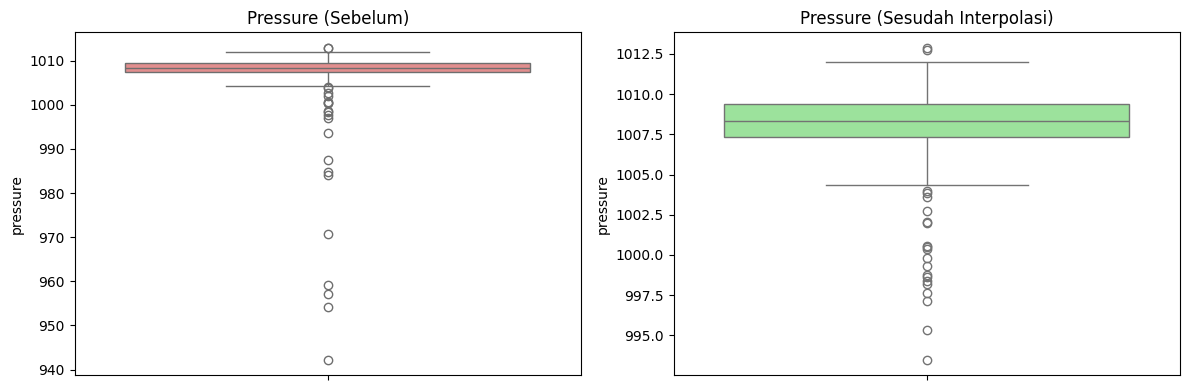


3. lanjut beresin fitur (drop konstan, rename, smoothing)...
   -> drop kolom konstan: ['netrad', 'ta_min', 'ta_max', 'pancilevel', 'pancitemp']

4. cek korelasi fitur akhir...


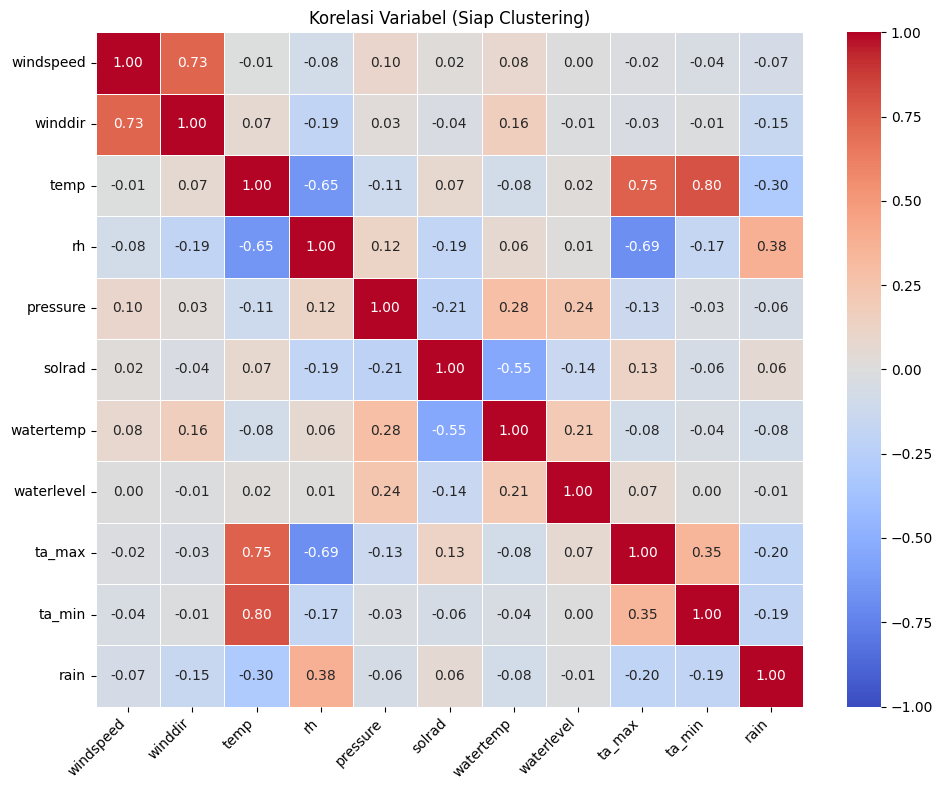


list fitur yg terlalu mirip (|r| > 0.80):
- temp & ta_min (r = 0.80)

pertimbangkan untuk mengeliminasi salah satu variabel yg berkorelasi tinggi

5. pipeline kelar! data disave ke:
-> /content/drive/MyDrive/dataset/data-aws-harian-final-clustering.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# mount drive
drive.mount('/content/drive')

# set path file
file_bersih = '/content/drive/MyDrive/dataset/data-aws-harian-bersih-2021-2025.xlsx'
file_final = '/content/drive/MyDrive/dataset/data-aws-harian-final-clustering.xlsx'

try:
    print("1. load data bersih...")
    df = pd.read_excel(file_bersih, index_col='waktu')

    # ==========================================
    # TAHAP 1: PENANGANAN OUTLIER PRESSURE (< 990)
    # ==========================================
    print("\n2. cek & benerin outlier pressure (< 990 hPa)...")
    if 'pressure' in df.columns:
        press_asli = df['pressure'].copy()
        mask_outlier = df['pressure'] < 990
        jml_outlier = mask_outlier.sum()

        if jml_outlier > 0:
            print(f"   -> ketemu {jml_outlier} baris anomali. proses interpolasi...")
            df.loc[mask_outlier, 'pressure'] = np.nan
            df['pressure'] = df['pressure'].interpolate(method='linear').bfill().ffill()
        else:
            print("   -> aman, ga ada anomali di bawah 990.")

        # nampilin boxplot before-after
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        sns.boxplot(y=press_asli, ax=ax[0], color='lightcoral')
        ax[0].set_title('Pressure (Sebelum)')

        sns.boxplot(y=df['pressure'], ax=ax[1], color='lightgreen')
        ax[1].set_title('Pressure (Sesudah Interpolasi)')
        plt.tight_layout()
        plt.show()

    # ==========================================
    # TAHAP 2: FEATURE PREP (Drop, Rename, Smooth)
    # ==========================================
    print("\n3. lanjut beresin fitur (drop konstan, rename, smoothing)...")

    # drop kolom konstan
    const_cols =[c for c in df.columns if df[c].nunique() <= 1]
    if const_cols:
        df.drop(columns=const_cols, inplace=True)
        print(f"   -> drop kolom konstan: {const_cols}")

    # beresin nama kolom
    if 'curah_hujan' in df.columns:
        df.drop(columns=['curah_hujan'], inplace=True)

    rename_dict = {
        'curah_hujan_capped': 'rain',
        'suhu_rata_rata': 'temp',
        'suhu_maksimum': 'ta_max',
        'suhu_minimum': 'ta_min'
    }
    df.rename(columns=rename_dict, inplace=True)

    # rolling average 3 harian (smoothing)
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].rolling(window=3, min_periods=1).mean()

    # ==========================================
    # TAHAP 3: KORELASI & HEATMAP
    # ==========================================
    print("\n4. cek korelasi fitur akhir...")

    # hitung korelasi langsung dari df
    corr = df[num_cols].corr(method='pearson')

    # plotting heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
    plt.title('Korelasi Variabel (Siap Clustering)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # cek redundansi
    print("\nlist fitur yg terlalu mirip (|r| > 0.80):")
    ada_redundant = False

    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            r_val = corr.iloc[i, j]
            if abs(r_val) > 0.80:
                ada_redundant = True
                print(f"- {corr.columns[i]} & {corr.columns[j]} (r = {r_val:.2f})")

    if ada_redundant:
        print("\npertimbangkan untuk mengeliminasi salah satu variabel yg berkorelasi tinggi")
    else:
        print("- aman, ga ada fitur yg redundant berlebihan.")

    # ==========================================
    # TAHAP 4: SAVE FINAL
    # ==========================================
    df.to_excel(file_final)
    print(f"\n5. pipeline kelar! data disave ke:\n-> {file_final}")

except FileNotFoundError:
    print("error: file tidak ditemukan")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/dataset/data-aws-harian-final-clustering.xlsx'

print("loading data...")
df = pd.read_excel(file_path)
if 'waktu' in df.columns:
    df['waktu'] = pd.to_datetime(df['waktu'])
    df.set_index('waktu', inplace=True)

# simpan data asli (yg udh di-smoothing di cell 3) sblm di-scale buat bikin profil ntar
df_asli = df.copy()

# 1. feature selection
#
fitur_pilih = ['windspeed', 'temp', 'rh', 'pressure', 'ta_max' , 'rain']
df_features = df[fitur_pilih].copy()

# 2. log transform buat hujan (biar ga skew gara-gara hujan ekstrem)
df_features['rain'] = np.log1p(df_features['rain'])

# 3. scaling
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns, index=df_features.index)

# 4. PCA (ambil 95% varians)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(df_scaled)

print(f"PCA berhasil mengekstrak {X_pca.shape[1]} komponen dari {len(fitur_pilih)} fitur awal.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loading data...
PCA berhasil mengekstrak 5 komponen dari 6 fitur awal.


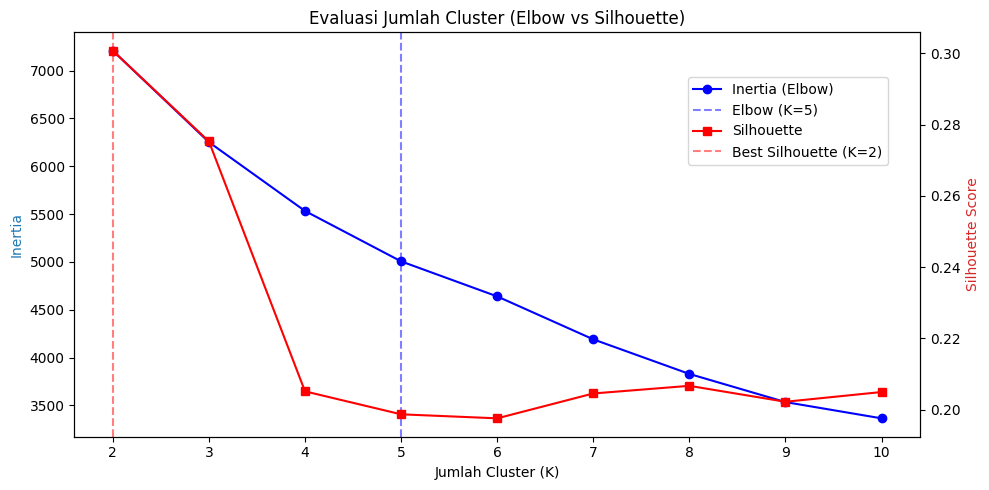

Rekomendasi Elbow: K=5
Rekomendasi Silhouette: K=2
-> Set final K = 2


In [ ]:
# cari jumlah cluster (K) yg paling optimal
K_range = range(2, 11)
inertias = []
sil_scores =[]

# fungsi custom buat nyari titik siku (elbow) secara matematis
def cari_titik_elbow(inertias):
    n = len(inertias)
    coords = np.vstack((range(n), inertias)).T
    line_vec = coords[-1] - coords[0]
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
    vec_from_first = coords - coords[0]
    scalar_proj = np.sum(vec_from_first * np.tile(line_vec_norm, (n, 1)), axis=1)
    vec_proj = np.outer(scalar_proj, line_vec_norm)
    vec_to_line = vec_from_first - vec_proj
    dist_to_line = np.sqrt(np.sum(vec_to_line ** 2, axis=1))
    return np.argmax(dist_to_line) + 2

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

k_elbow = cari_titik_elbow(inertias)
k_sil = K_range[np.argmax(sil_scores)]

# plotting
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.plot(K_range, inertias, 'bo-', label='Inertia (Elbow)')
ax1.axvline(x=k_elbow, color='b', linestyle='--', alpha=0.5, label=f'Elbow (K={k_elbow})')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, sil_scores, 'rs-', label='Silhouette')
ax2.axvline(x=k_sil, color='r', linestyle='--', alpha=0.5, label=f'Best Silhouette (K={k_sil})')

plt.title('Evaluasi Jumlah Cluster (Elbow vs Silhouette)')
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.85))
plt.tight_layout()
plt.show()

print(f"Rekomendasi Elbow: K={k_elbow}")
print(f"Rekomendasi Silhouette: K={k_sil}")

# Pake hasil Silhouette karena lebih objektif ngukur separasi cluster
optimal_k = k_sil
print(f"-> Set final K = {optimal_k}")

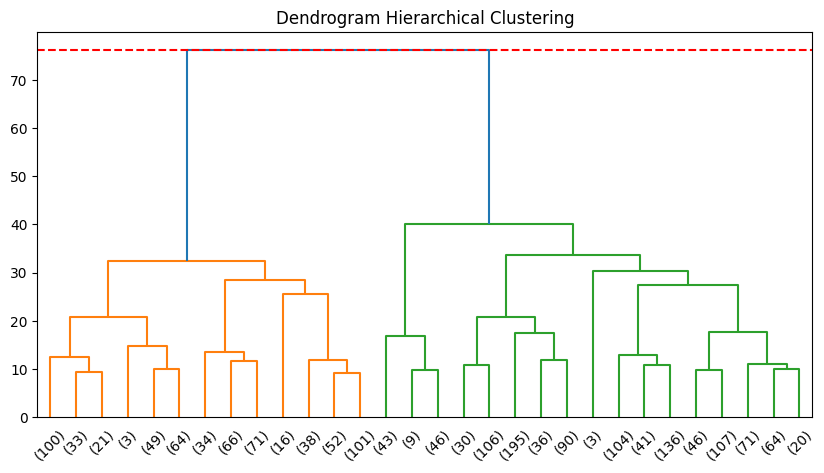


--- Perbandingan Evaluasi Model ---


,Metode,Silhouette Score (↑),Calinski-Harabasz (↑),Davies-Bouldin (↓)
0,K-Means,0.300740,790.566881,1.325738
1,Hierarchical (Ward),0.276592,695.100235,1.378168


In [ ]:
# 1. run K-Means final
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

# 2. run Hierarchical (Ward Linkage)
# tampilin dendrogram dulu
linked = linkage(X_pca, method='ward', metric='euclidean')
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.axhline(y=linked[-optimal_k+1, 2] if optimal_k > 1 else linked[-1, 2], color='r', linestyle='--')
plt.title('Dendrogram Hierarchical Clustering')
plt.show()

hc = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(X_pca)

# 3. Evaluasi performa model
eval_df = pd.DataFrame({
    'Metode':['K-Means', 'Hierarchical (Ward)'],
    'Silhouette Score (↑)':[
        silhouette_score(X_pca, kmeans_labels),
        silhouette_score(X_pca, hc_labels)
    ],
    'Calinski-Harabasz (↑)':[
        calinski_harabasz_score(X_pca, kmeans_labels),
        calinski_harabasz_score(X_pca, hc_labels)
    ],
    'Davies-Bouldin (↓)':[
        davies_bouldin_score(X_pca, kmeans_labels),
        davies_bouldin_score(X_pca, hc_labels)
    ]
})

print("\n--- Perbandingan Evaluasi Model ---")
display(eval_df)

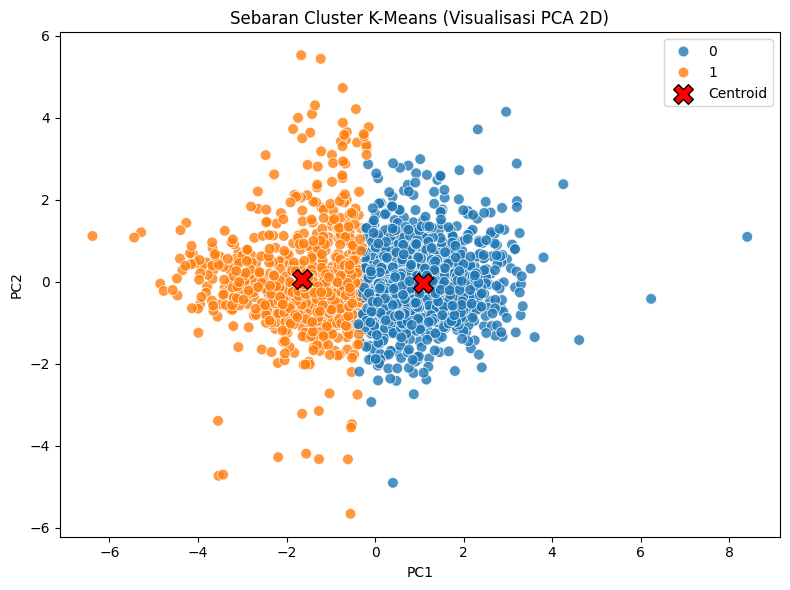


--- Rata-Rata Kondisi Cuaca Per Cluster ---


,windspeed,temp,rh,pressure,ta_max,rain
Cluster,,,,,,
0,1.128454,27.110623,84.220352,1008.415817,31.485640,12.578350
1,1.173767,28.662725,77.069794,1008.031308,33.381087,4.033239



--- Interpretasi (Semantik Label) ---
Cluster 0 : Cuaca Basah dengan Kelembapan Tinggi
Cluster 1 : Cuaca Panas dan Relatif Kering


In [ ]:
# 1. Visualisasi 2D pake PCA
df_vis = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
df_vis['Cluster'] = kmeans_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='tab10', data=df_vis, s=60, alpha=0.8)

centroids = kmeans.cluster_centers_[:, :2]
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', edgecolor='k', label='Centroid')
plt.title('Sebaran Cluster K-Means (Visualisasi PCA 2D)')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Profiling (Balikin ke data suhu Celcius & hujan mm yg asli)
df_asli['Cluster'] = kmeans_labels
cluster_means = df_asli.groupby('Cluster')[['windspeed', 'temp', 'rh', 'pressure', 'ta_max', 'rain']].mean()

print("\n--- Rata-Rata Kondisi Cuaca Per Cluster ---")
display(cluster_means)

print("\n--- Interpretasi (Semantik Label) ---")
for c in range(optimal_k):
    row = cluster_means.loc[c]

    # Simple logic tagging
    if row['rain'] >= 10 and row['rh'] >= 80:
        label = "Cuaca Basah dengan Kelembapan Tinggi"

    elif row['ta_max'] >= 33 and row['rh'] < 80:
        label = "Cuaca Panas dan Relatif Kering"

    elif row['windspeed'] >= 3.5:
        label = "Cuaca Berangin"

    elif row['rh'] >= 85:
        label = "Cuaca Lembap"

    else:
        label = "Cuaca Normal"

    print(f"Cluster {c} : {label}")